In [1]:
# 1 Частина
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
import re
import string
import random
import math
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Device: cuda


In [2]:
import os
DATA_DIR = "/content"

texts = []

for filename in os.listdir(DATA_DIR):
    if filename.endswith(".txt"):
        path = os.path.join(DATA_DIR, filename)
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            texts.append(f.read())

print(f"Завантажено файлів: {len(texts)}")
print(texts[0][:500])

Завантажено файлів: 4
Лісова пісня
Українка Леся 


ПРОЛОГ
 
"Той, що греблі рве".       Русалка. 
Потерчата (двоє).         Водяник.
 
ДІЯ І
 
Дядько Лев.              Перелесник. 
Лукаш.                  Пропасниця (без мови). 
Русалка.               Потерчата. 
Лісовик.                 Куць.
Мавка.
 
ДІЯ II
 
Мати Лукашева.  Килина.
Лукаш.                     Русалка.
Дядько Лев.                "Той, що в скалі
Мавка.                        сидить".
Русалка Польова.     Перелесник.
 
ДІЯ III
 
Мавка.              


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^а-щьюяєіїґ\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()
cleaned_texts = [clean_text(t) for t in texts]
tokens = [word_tokenize(t) for t in cleaned_texts]

print(tokens[0][:20])

['лісова', 'пісня', 'українка', 'леся', 'пролог', 'той', 'що', 'греблі', 'рве', 'русалка', 'потерчата', 'двоє', 'водяник', 'дія', 'і', 'дядько', 'лев', 'перелесник', 'лукаш', 'пропасниця']


In [4]:
counter = Counter()
for tok_list in tokens:
    counter.update(tok_list)

print("Унікальних слів:", len(counter))

MAX_VOCAB = 30_000

specials = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
most_common = counter.most_common(MAX_VOCAB - len(specials))

itos = specials + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]
BOS_IDX = stoi["[BOS]"]
EOS_IDX = stoi["[EOS]"]

print("Розмір словника:", len(stoi))

Унікальних слів: 39046
Розмір словника: 30000


In [5]:
MAX_LEN = 100
def encode_with_specials(tok_list):
    ids = [stoi.get(t, UNK_IDX) for t in tok_list]
    ids = ids[:MAX_LEN - 2]
    return [BOS_IDX] + ids + [EOS_IDX]
encoded_texts = [encode_with_specials(tok_list) for tok_list in tokens]
print(encoded_texts[0][:20])
def pad_sequence(seq):
    seq = seq[:MAX_LEN]
    seq = seq + [PAD_IDX] * (MAX_LEN - len(seq))
    return torch.tensor(seq, dtype=torch.long)
def make_lm_pair(seq):
    return seq[:-1], seq[1:]
pairs = [make_lm_pair(seq) for seq in encoded_texts]

X_in  = torch.stack([pad_sequence(inp) for inp, _ in pairs])
Y_tgt = torch.stack([pad_sequence(tgt) for _, tgt in pairs])

print(X_in.shape, Y_tgt.shape)

[2, 3375, 665, 3376, 2930, 9095, 94, 7, 2931, 2560, 949, 2245, 6402, 2932, 2007, 4, 1254, 415, 2933, 377]
torch.Size([4, 100]) torch.Size([4, 100])


In [6]:
dataset = TensorDataset(X_in, Y_tgt)

VAL_FRAC = 0.25
val_size = int(len(dataset) * VAL_FRAC)
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [8]:
class TransformerDecoderLM(nn.Module):
    def __init__(self, vocab_size, emb_dim, pad_idx,
                 n_heads=4, n_layers=2, dim_ff=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.pos = PositionalEncoding(emb_dim)

        layer = nn.TransformerDecoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=dim_ff,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(layer, n_layers)
        self.fc = nn.Linear(emb_dim, vocab_size)
        self.pad_idx = pad_idx

    def _mask(self, T, device):
        return torch.triu(torch.ones(T, T, device=device), 1).bool()

    def forward(self, x):
        emb = self.pos(self.embedding(x))
        T = x.size(1)
        mask = self._mask(T, x.device)
        out = self.decoder(
            emb, emb,
            tgt_mask=mask,
            tgt_key_padding_mask=(x == self.pad_idx)
        )
        return self.fc(out)

In [9]:
model = TransformerDecoderLM(
    vocab_size=len(stoi),
    emb_dim=128,
    pad_idx=PAD_IDX
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
def train_epoch(model, loader):
    model.train()
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)
def eval_epoch(model, loader):
    model.eval()
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            total += loss.item()
    return total / len(loader)
EPOCHS = 20
for e in range(1, EPOCHS + 1):
    tr = train_epoch(model, train_loader)
    vl = eval_epoch(model, val_loader)
    print(f"Epoch {e}: train={tr:.4f}, val={vl:.4f}")


Epoch 1: train=10.4428, val=10.5336
Epoch 2: train=10.0697, val=10.4851
Epoch 3: train=9.7365, val=10.4434
Epoch 4: train=9.4542, val=10.4076
Epoch 5: train=9.2344, val=10.3769
Epoch 6: train=9.0064, val=10.3469
Epoch 7: train=8.7723, val=10.3193
Epoch 8: train=8.5422, val=10.2930
Epoch 9: train=8.3209, val=10.2686
Epoch 10: train=8.0704, val=10.2449
Epoch 11: train=7.8267, val=10.2235
Epoch 12: train=7.5728, val=10.2040
Epoch 13: train=7.3383, val=10.1877
Epoch 14: train=7.0875, val=10.1749
Epoch 15: train=6.8515, val=10.1641
Epoch 16: train=6.6324, val=10.1543
Epoch 17: train=6.3962, val=10.1470
Epoch 18: train=6.1741, val=10.1445
Epoch 19: train=5.9400, val=10.1498
Epoch 20: train=5.7130, val=10.1642


In [10]:
itos_inv = {i: w for w, i in stoi.items()}
def generate(model, start_text, max_new_tokens=30, temperature=1.0):
    model.eval()
    tokens = word_tokenize(clean_text(start_text))
    ids = [BOS_IDX] + [stoi.get(t, UNK_IDX) for t in tokens]

    seq = torch.tensor([ids], device=device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(seq)
            next_logits = logits[0, -1] / temperature
            probs = torch.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, 1).item()
            seq = torch.cat([seq, torch.tensor([[next_id]], device=device)], dim=1)
            if next_id == EOS_IDX:
                break

    words = [
        itos_inv[i] for i in seq[0].tolist()
        if i not in (PAD_IDX, BOS_IDX, EOS_IDX)
    ]
    return " ".join(words)
print(generate(model, "і прийшла весна", max_new_tokens=40))

і прийшла весна з породи неславу засенко перекладні дзінка прозаїк зелену зло страшенна чоловіків медведева двоє він кінцеве ненум мов запруди т передзахідного покидає доля замку дальшу п сконаю закоханий регаючий на тріском тогочасного документах надійшла діти перебороти ідеться найслабше виволікає засилаюсь з


In [11]:
# 2 Частина
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
image_size = 32
nc = 3
latent_dim = 100
batch_size = 128
epochs = 100

Device: cuda


In [12]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

train_dataset = datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

print("Train samples:", len(train_dataset))
print("One image shape:", train_dataset[0][0].shape)

100%|██████████| 169M/169M [00:12<00:00, 13.2MB/s]


Train samples: 50000
One image shape: torch.Size([3, 32, 32])


In [13]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, 64, 3, 1, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.4),
            nn.Conv2d(128, 128, 3, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.4),
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.4),

            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [14]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256 * 4 * 4),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.conv = nn.Sequential(

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(128, 128, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, nc, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 4, 4)
        return self.conv(x)

In [15]:
discriminator = Discriminator().to(device)
generator = Generator().to(device)

criterion = nn.BCELoss()

d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [16]:
def denorm(x):
    return (x + 1) / 2

def plot_generated_images(epoch, generator, num_images=10):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake = generator(z).cpu()
        fake = denorm(fake)

    plt.figure(figsize=(20, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = fake[i].permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()

    generator.train()

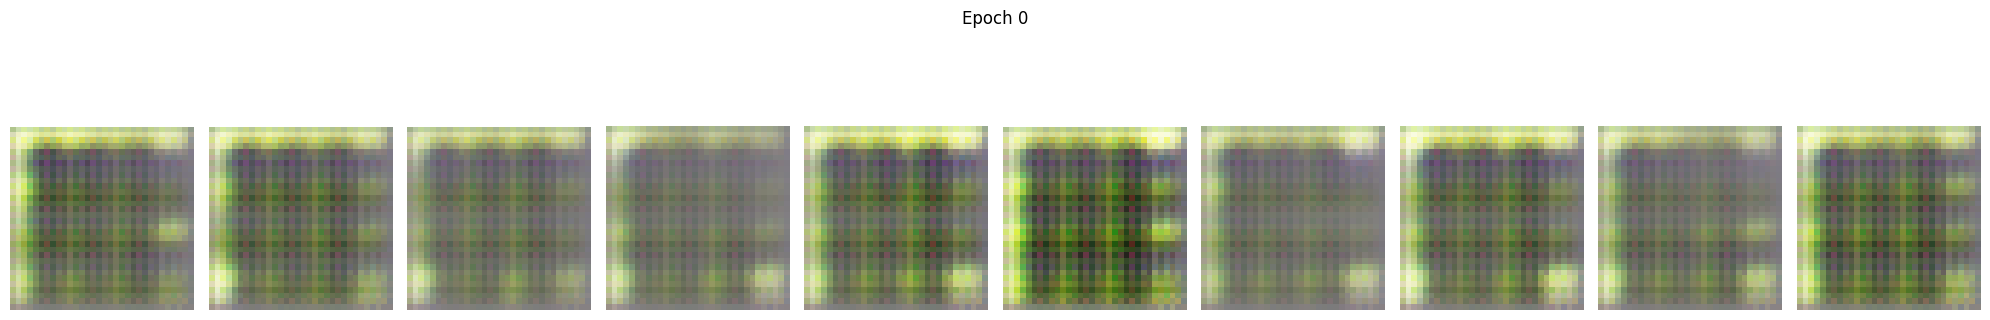

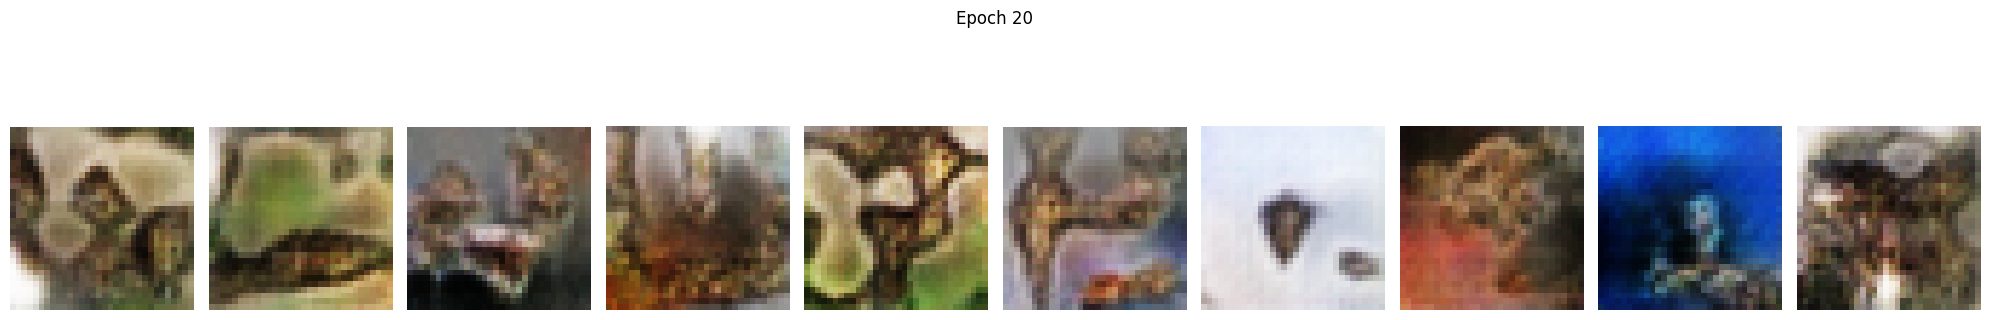

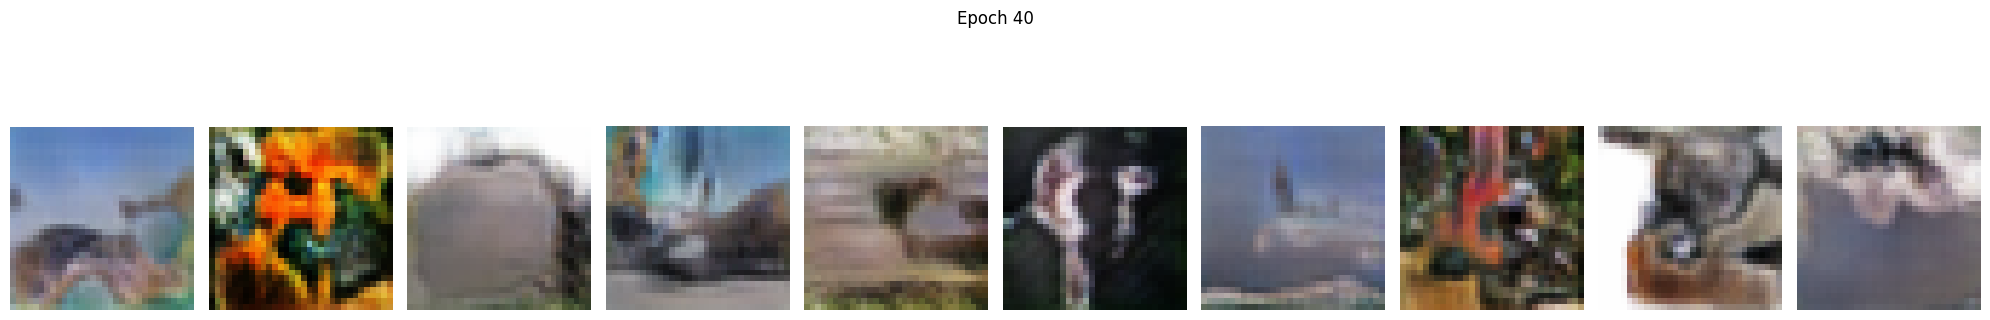

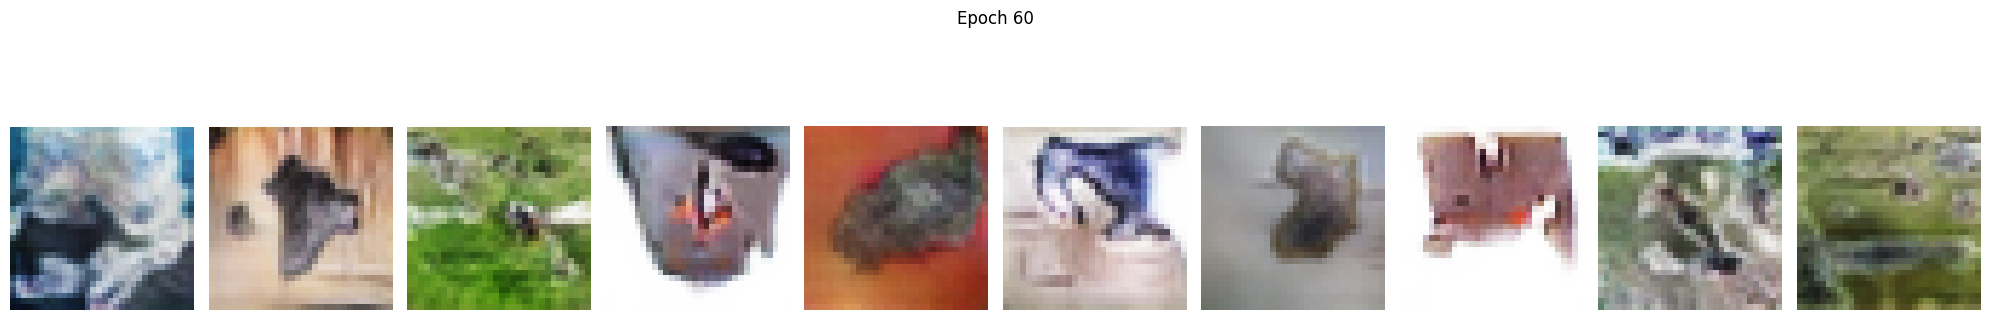

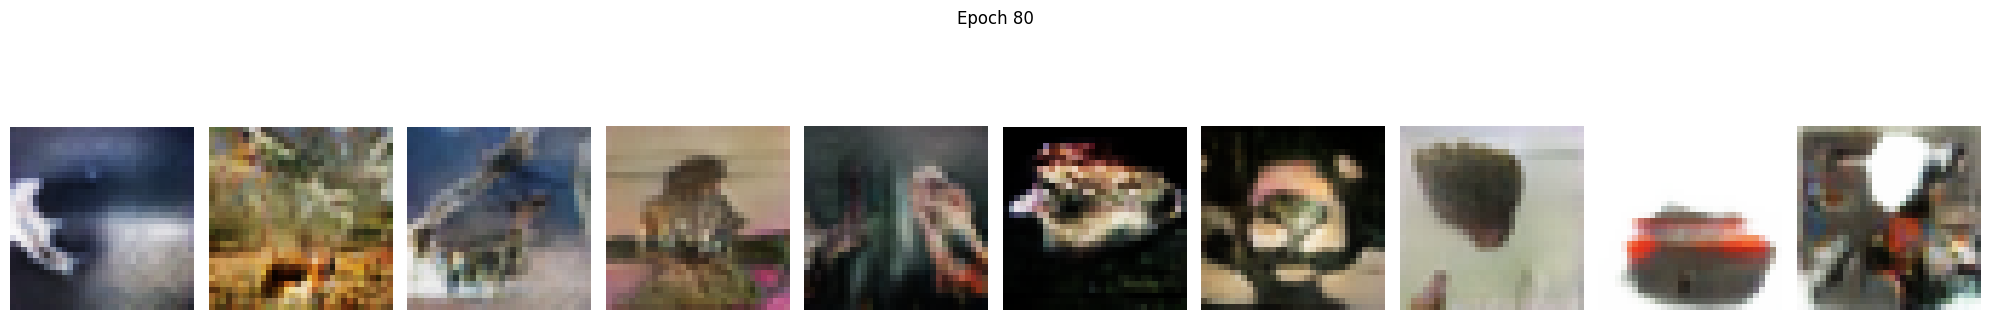

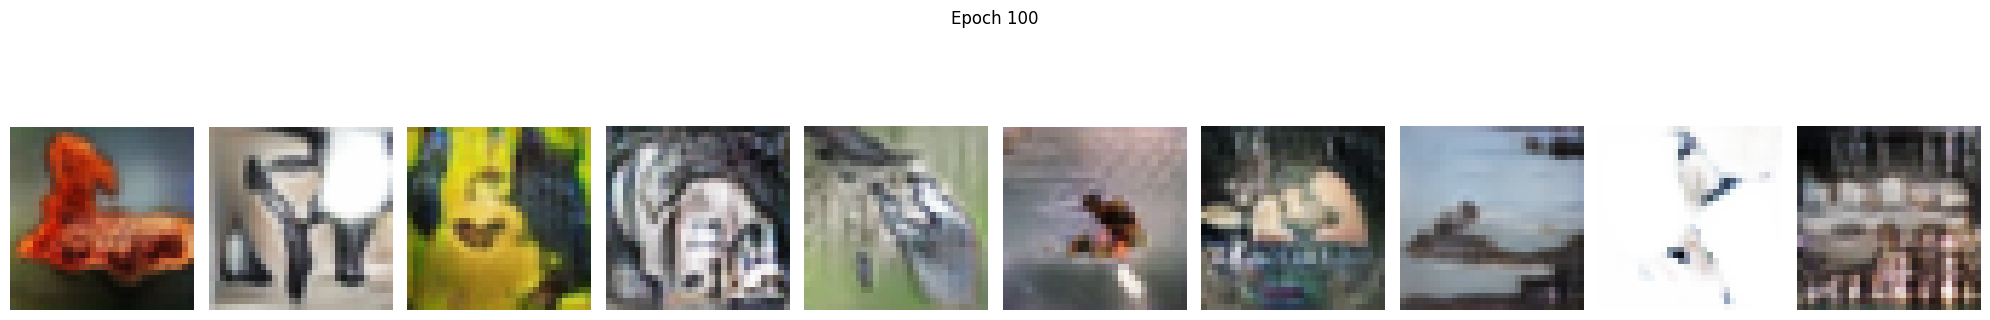

Тренування 3811.6 сек (~63.53 хв)


In [17]:
def train_dcgan(epochs):
    for epoch in range(epochs + 1):
        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            b_size = real_images.size(0)

            real_labels = torch.full((b_size, 1), 0.9, device=device)
            fake_labels = torch.zeros(b_size, 1, device=device)

            outputs_real = discriminator(real_images)
            d_loss_real = criterion(outputs_real, real_labels)

            z = torch.randn(b_size, latent_dim, device=device)
            fake_images = generator(z)
            outputs_fake = discriminator(fake_images.detach())
            d_loss_fake = criterion(outputs_fake, fake_labels)

            d_loss = d_loss_real + d_loss_fake

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            z = torch.randn(b_size, latent_dim, device=device)
            fake_images = generator(z)
            outputs = discriminator(fake_images)

            g_loss = criterion(outputs, real_labels)

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        if epoch % 20 == 0:
            plot_generated_images(epoch, generator)
start = time.perf_counter()
train_dcgan(epochs)
end = time.perf_counter()

print(f"Тренування {end - start:.1f} сек (~{(end - start)/60:.2f} хв)")

In [18]:
# 3 Частина(а)
!pip install -q transformers pandas torch scikit-learn
import torch
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report
from tqdm.notebook import tqdm

device = 0 if torch.cuda.is_available() else -1
print("Device:", "cuda" if device == 0 else "cpu")

Device: cuda


In [19]:
fake_df = pd.read_csv("/content/Fake.csv")
true_df = pd.read_csv("/content/True.csv")

fake_df["label"] = 0
true_df["label"] = 1
df = pd.concat([fake_df, true_df], ignore_index=True)

N = 5000
df = df.sample(n=N, random_state=42).reset_index(drop=True)
print(f"Processing {len(df)} samples...")

texts = df["text"].tolist()
labels = df["label"].tolist()

Processing 5000 samples...


In [20]:
pipe_roberta = pipeline(
    "text-classification",
    model="hamzab/roberta-fake-news-classification",
    device=device,
    truncation=True,
    max_length=512
)

preds_roberta = []
print("Running RoBERTa Fake News...")
for t in tqdm(texts):
    out = pipe_roberta(t)[0]["label"]
    preds_roberta.append(1 if "1" in out else 0)

print("\n=== RoBERTa Fake News Report ===")
print("Accuracy:", accuracy_score(labels, preds_roberta))
print(classification_report(labels, preds_roberta, target_names=["Fake", "Real"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/789 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

...

Running RoBERTa Fake News...


  0%|          | 0/5000 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



=== RoBERTa Fake News Report ===
Accuracy: 0.53
              precision    recall  f1-score   support

        Fake       0.53      1.00      0.69      2650
        Real       0.00      0.00      0.00      2350

    accuracy                           0.53      5000
   macro avg       0.27      0.50      0.35      5000
weighted avg       0.28      0.53      0.37      5000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
zero_shot_model = "facebook/bart-large-mnli"

pipe_zero = pipeline(
    "zero-shot-classification",
    model=zero_shot_model,
    device=device
)

candidate_labels = ["fake news", "real news"]
preds_zero = []

print(f"Running Zero-Shot with {zero_shot_model}...")

for t in tqdm(texts):
    out = pipe_zero(
        t[:800],
        candidate_labels=candidate_labels
    )
    if out["labels"][0] == "fake news":
        preds_zero.append(0)
    else:
        preds_zero.append(1)

print("\n=== Zero-Shot Classification Report ===")
print("Model:", zero_shot_model)
print("Accuracy:", accuracy_score(labels, preds_zero))
print(classification_report(labels, preds_zero, target_names=["Fake", "Real"]))

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Running Zero-Shot with facebook/bart-large-mnli...


  0%|          | 0/5000 [00:00<?, ?it/s]


=== Zero-Shot Classification Report ===
Model: facebook/bart-large-mnli
Accuracy: 0.4954
              precision    recall  f1-score   support

        Fake       0.81      0.06      0.12      2650
        Real       0.48      0.98      0.65      2350

    accuracy                           0.50      5000
   macro avg       0.65      0.52      0.38      5000
weighted avg       0.66      0.50      0.37      5000



In [23]:
# 3 Частина(с)
!pip install -q diffusers transformers accelerate safetensors
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


In [24]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None
)

pipe = pipe.to(device)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [25]:
prompt = (
    "The Carpathian mountains in Ukraine, a cozy small wooden cabin, "
    "ethereal morning mist, epic landscape photography, cinematic lighting, hyper-realistic"
)

negative_prompt = "low resolution, blurry, distorted, cartoon, low quality, watermarks"

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=35,
    guidance_scale=8.5,
).images[0]

  0%|          | 0/35 [00:00<?, ?it/s]

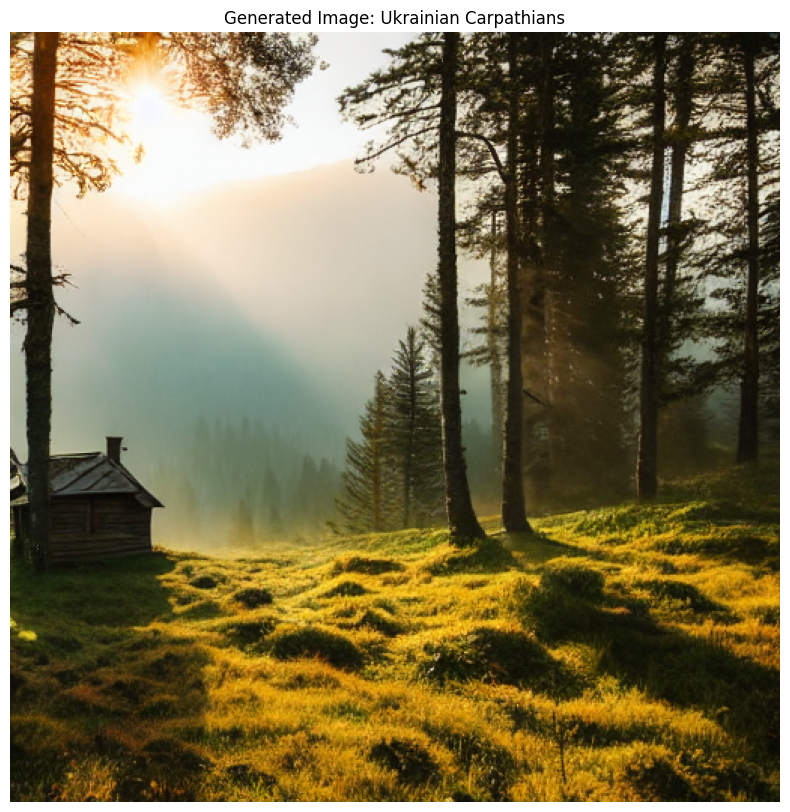

In [26]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Image: Ukrainian Carpathians")
plt.show()